In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cd /content/drive/MyDrive/data/stone/

/content/drive/MyDrive/data/stone


In [3]:
data_root = '/content/drive/MyDrive/data/stone/'
train_dir = os.path.join(data_root, 'npy/train')
val_dir = os.path.join(data_root, 'npy/val')
test_dir = os.path.join(data_root, 'npy/test')

## 데이터 체크

Loaded 1000 images with shape (64, 64, 3)


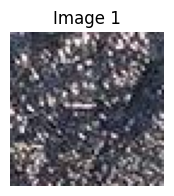

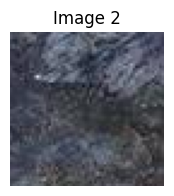

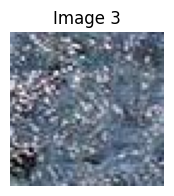

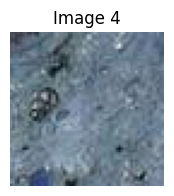

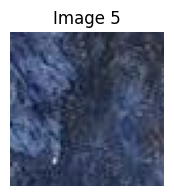

In [4]:
# 저장된 npy 파일 경로
npy_path = train_dir+'/Andesite_000002.npy'

# 1. npy 파일 읽기
images = np.load(npy_path)  # shape: (1000, 64, 64, 3)

print(f"Loaded {images.shape[0]} images with shape {images.shape[1:]}")

# 2. 앞의 5개 이미지 시각화
for i in range(5):
    plt.figure(figsize=(2, 2))
    plt.imshow(images[i])
    plt.title(f"Image {i+1}")
    plt.axis('off')
    plt.show()


## 딥러닝 모델 구성

In [38]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# 사전 학습된 ResNet50을 불러오되, top layer (fully connected) 제거
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# 가중치 동결 (학습되지 않도록 설정)
base_model.trainable = False

# 전체 모델 구성
model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())  # 또는 Flatten()
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))  # 7개 클래스 분류

# 학습 설정
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [39]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

### 베이스 모델의 일부만 가져와 사용하는 경우 (함수형)

In [29]:
# from tensorflow.keras.models import Model

# # 2. 특정 레이어까지 잘라서 feature extractor로 사용
# layer_name = 'conv3_block4_out'  # Conv3 끝까지 사용
# x = base_model.get_layer(layer_name).output

# x = GlobalAveragePooling2D()(x)  # 또는 Flatten()

# x = Dense(128, activation='relu')(x)
# x = Dropout(0.5)(x)
# output = Dense(7, activation='softmax')(x)

# # 5. 새로운 전체 모델 정의
# model = Model(inputs=base_model.input, outputs=output)

# # 학습 설정
# optimizer = Adam(learning_rate=0.001)
# model.compile(optimizer=optimizer,
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 학습

In [41]:
import os
import numpy as np
import random
from tensorflow.keras.utils import to_categorical

# 클래스 정의
class_names = ['Andesite', 'Basalt', 'Gneiss', 'Granite', 'Mud_Sandstone', 'Weathered_Rock', 'Etc']
num_classes = len(class_names)
class_to_label = {name: i for i, name in enumerate(class_names)}



In [42]:
# Validation 데이터 로딩 함수
def load_validation_data():
    X_val, y_val = [], []
    for class_name in class_names:
        files = [f for f in os.listdir(val_dir) if f.startswith(class_name) and f.endswith('.npy')]
        for f in files:
            path = os.path.join(val_dir, f)
            imgs = np.load(path)/255
            labels = np.full((len(imgs),), class_to_label[class_name])
            X_val.append(imgs)
            y_val.append(labels)

    X_val = np.concatenate(X_val, axis=0)
    y_val = np.concatenate(y_val, axis=0)
    y_val = to_categorical(y_val, num_classes=num_classes)
    return X_val, y_val

# Validation 데이터 미리 로딩
X_val, y_val = load_validation_data()

In [43]:
# 랜덤하게 각 클래스에서 파일을 선택하여 배치를 구성한다.
def get_batch(batch_size_per_class):
    X_batch = []
    y_batch = []

    for class_name in class_names:
        class_files = [f for f in os.listdir(train_dir) if f.startswith(class_name) and f.endswith('.npy')]

        selected_file = random.choice(class_files)
        file_path = os.path.join(train_dir, selected_file)

        # .npy 파일 로딩 (이미지는 (N, 64, 64, 3) 형태)
        images = np.load(file_path)/255

        # 사용할 샘플 수
        num_images = len(images)

        sample_size = min(batch_size_per_class, num_images)  # 파일 내 이미지가 기본 배치 사이즈보다 적으면 전부 사용

        # 무작위로 sample_size만큼 인덱스 선택
        selected_indices = np.random.choice(num_images, sample_size, replace=False)

        # 선택한 이미지와 라벨만 사용
        selected_images = images[selected_indices]
        selected_labels = np.full((sample_size,), class_to_label[class_name])


        # 배치에 추가
        X_batch.append(selected_images)
        y_batch.append(selected_labels)

    # 배치 구성
    X_batch = np.concatenate(X_batch, axis=0)
    y_batch = np.concatenate(y_batch, axis=0)

    # Shuffle
    indices = np.arange(len(X_batch))
    np.random.shuffle(indices)
    X_batch = X_batch[indices]
    y_batch = y_batch[indices]

    # 라벨 one-hot 인코딩
    y_batch = to_categorical(y_batch, num_classes=num_classes)

    return X_batch, y_batch

In [ ]:
import gc
from keras import backend as K
K.clear_session()

# 학습 루프
epochs = 200
steps_per_epoch = 50  # 또는 원하는 횟수
batch_size_per_class = 128

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    loss = 0
    acc = 0

    for step in range(steps_per_epoch):
        # 랜덤하게 각 클래스에서 파일을 선택하여 배치를 구성
        X_batch, y_batch = get_batch(batch_size_per_class)

        # 학습
        loss_tmp, acc_tmp = model.train_on_batch(X_batch, y_batch)

        loss += loss_tmp
        acc += acc_tmp

        #메모리 관리
        X_batch = None
        y_batch = None
        del X_batch, y_batch
        gc.collect()
        print('.',end='')
    print('')

    # step별 loss, acc의 평균
    loss /= steps_per_epoch
    acc /= steps_per_epoch

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f'loss: {loss:.4f}, acc: {acc:.4f},  val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')
    model.save(f'mymodel.keras')


Epoch 1/200
..................................................
loss: 2.0376, acc: 0.1497,  val_loss: 1.9398, val_acc: 0.2261
Epoch 2/200
..................................................
loss: 1.9380, acc: 0.2028,  val_loss: 1.9315, val_acc: 0.2116
Epoch 3/200
..................................................
loss: 1.9285, acc: 0.2073,  val_loss: 1.9223, val_acc: 0.2220
Epoch 4/200
..................................................
loss: 1.9157, acc: 0.2148,  val_loss: 1.9138, val_acc: 0.1804
Epoch 5/200
..................................................
loss: 1.9066, acc: 0.2041,  val_loss: 1.9000, val_acc: 0.2063
Epoch 6/200
..................................................
loss: 1.8930, acc: 0.2223,  val_loss: 1.8861, val_acc: 0.2051
Epoch 7/200
..................................................
loss: 1.8904, acc: 0.2139,  val_loss: 1.8825, val_acc: 0.2391
Epoch 8/200
..................................................
loss: 1.8904, acc: 0.2293,  val_loss: 1.8789, val_acc: 0.2276


## 예측

In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# 경로 설정
model_path = './mymodel.keras'
submission_template = './sample_submission.csv'
output_csv = './my_submission.csv'

# 모델 로딩
model = load_model(model_path)

# sample_submission 틀 불러오기
df_submission = pd.read_csv(submission_template)

# 결과를 담을 리스트
predicted_labels = []

# test_dir에서 npy 파일들을 정렬하여 순서대로 처리
test_files = sorted([f for f in os.listdir(test_dir) if f.endswith('.npy')])

for file_name in test_files:
    file_path = os.path.join(test_dir, file_name)
    images = np.load(file_path) / 255.0  # 정규화

    # 배치 예측
    preds = model.predict(images, verbose=0)
    class_indices = np.argmax(preds, axis=1)

    # 클래스 이름으로 변환하여 추가
    predicted_labels.extend([class_names[i] for i in class_indices])

# sample_submission에 예측 결과 삽입
df_submission['rock_type'] = predicted_labels

# 저장
df_submission.to_csv(output_csv, index=False)
print(f'Submission saved to: {output_csv}')
